# 2026-10-07 Intrinsic [N II] 6583 dispersion: NSF and TNSF

Absolute dispersion profiles only, for **NSF**, **NSF + EW(Halpha)<3**,
**TNSF**, and **TNSF + EW(Halpha)<3**. The first comparison figure uses
equal galaxy weighting; the second uses pooled supported pixels. Each figure
has the same four rows and two columns (stellar-mass surface density and radius).
All y axes span **0--120 km/s**. This display cap does not filter or clip
individual measurements, medians or bootstrap draws. Values outside the display
range remain in the numerical tables.

NSF uses the inherited Balmer-detected complement of SF. TNSF is
`NSF & (NII_BPT == 3)`. The EW subsets require finite `PROXY_EWHA < 3`;
exactly 3 Angstrom is excluded. The parent SF definition retains EW>6 and
intrinsic sigma<45 km/s. All selections use the same usable disc and strict
`SNR_POSTFIT > 25` footprint. These four selections overlap, rather than forming
an exhaustive partition. The source notebooks are unchanged.

Intrinsic dispersion is $\sqrt{\sigma_{\rm obs}^2-\sigma_{\rm corr}^2}$;
non-positive radicands remain unavailable. The inherited galaxy sample, geometry,
binning and 10,000 whole-galaxy bootstrap draws are retained. Profile support
now additionally requires at least 25 distinct selected gas bins per
galaxy/interval, counted from NSF only.
Stage comparisons involve different galaxies. Medians reduce the influence of broad fitted tails; bootstrap bands omit flux-fit, geometry and instrumental systematics.

**Shared NSF support:** All four selections use the same qualifying NSF galaxy
footprint in each interval: at least 50 usable pixels, 20 finite NSF dispersion
pixels and 25 distinct selected NSF gas bins per galaxy; at least five such
galaxies within each stage. The restricted selections are measured inside this
footprint without their own minimum pixel, gas-bin or galaxy-count cut. Their
actual finite-data contributor counts are reported separately from NSF support.
Rejected stage intervals have NaN estimates and bootstrap draws. The five-galaxy
gate is based on the observed NSF sample, not reapplied to bootstrap draws.

**Median estimators:** equal-galaxy points are medians of within-galaxy
medians; pooled points are medians of all supported finite pixels. Every
whole-galaxy bootstrap draw recomputes the corresponding median.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
NII6583_SIGMA_OBS_HDU = "NII6583_SIGMA"
NII6583_SIGMA_CORR_HDU = "NII6583_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
NII6583_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
FIXED_RELIABLE_RANGES = {"log_sigma_star": (7.0, 9.5), "radius_re": (0.0, 2.5)}
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})


BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
DIAGNOSTIC_MIN_PIXELS_PER_BIN = 20
MIN_DISTINCT_GAS_BINS_PER_BIN = 25
MIN_GALAXIES_PER_STAGE_BIN = 5
EW_HA_MAX_RESTRICTED = 3.0
DISPERSION_YLIM = (0.0, 120.0)
CATEGORY_ORDER = ("NSF", "NSF + EW(Halpha)<3", "TNSF", "TNSF + EW(Halpha)<3")
VARIABLES = ("log_sigma_star", "radius_re")
BRANCH_LABELS = {"equal": "Equal-galaxy median", "pooled": "Pooled-spaxel median"}
STAGE_COLORS = {"pre-peak": "#2166ac", "close-to-peak": "#1a9850", "post-peak": "#d73027"}
print(f"Project root: {PROJECT_ROOT}")
print("Scope: intrinsic [N II] 6583 dispersion only; four selections; display 0--120 km/s")

SOURCE_NOTEBOOK_SHA256 = {'20261006_check_emission_line_fading_BPT_ratios_Halpha_sigma_TNSF_by_stage.ipynb': '71844cfecef705d941152fd29e6e2d928d2e0c10de97ba077fc2d33f983cb2e9', '20261006_check_emission_line_fading_BPT_ratios_Halpha_sigma_NSF_by_stage.ipynb': '15499877f0e025c50370688f842ca58a976b4d42b4879534ef0f8e224a44bc10'}


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: intrinsic [N II] 6583 dispersion only; four selections; display 0--120 km/s


## Shared geometry, masks and live sample

Source mask and QC helpers retained; no forbidden-line detection gate is added to dispersion support.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, NII6583_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, NII6583_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < NII6583_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= NII6583_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3)
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_NSF": int(maps["nsf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")

,GALID,components,stage,inclination_deg,N_valid,N_NSF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,44751,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,34784,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,273584,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,124980,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,28047,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,9260,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,33508,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,64059,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,53545,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,46546,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


## Dispersion measurements and shared NSF support

Intervals have width 0.25. Support is decided solely from NSF: at least 50
usable-disc pixels, 20 finite NSF dispersion pixels and 25 distinct NSF gas
bins per galaxy/interval, followed by at least five qualifying NSF galaxies
per stage/interval. All four selections use those same qualifying galaxies.
Restricted subsets need only nonempty finite dispersion data to contribute;
their actual contributor counts may be below five.

Plot ranges remain density 7--9.5 and radius 0--2.5 Re. No radius cut is added.
The same whole-galaxy bootstrap draws are shared across selections and intervals.


In [4]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}

def nsf_profile_supported(frame):
    return (frame.eligible_usable
            & frame.N_sigma_NII6583.ge(DIAGNOSTIC_MIN_PIXELS_PER_BIN)
            & frame.N_unique_gas_bins.ge(MIN_DISTINCT_GAS_BINS_PER_BIN))


dispersion_rows, selection_rows = [], []
all_masks_exact = True
for row in sample.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry)
    keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
    sigma = maps["sigma_intrinsic"]
    ew = maps["ew_ha"]
    nsf = maps["nsf_mask"] & keep
    tnsf = nsf & (maps["nii_bpt_class"] == 3)
    ew_lt3 = np.isfinite(ew) & (ew < EW_HA_MAX_RESTRICTED)
    masks = dict(zip(CATEGORY_ORDER, (nsf, nsf & ew_lt3, tnsf, tnsf & ew_lt3)))
    all_masks_exact &= bool(np.array_equal(tnsf, maps["tnsf_mask"] & keep))
    assert not np.any(masks[CATEGORY_ORDER[1]] & ~nsf)
    assert not np.any(masks[CATEGORY_ORDER[3]] & ~tnsf)
    assert not np.any(tnsf & ~nsf)
    selection_rows.extend({"GALID": row.GALID, "stage": row.stage, "category": category,
        "N_usable": int(keep.sum()), "N_category": int(mask.sum()),
        "N_finite_sigma": int((mask & np.isfinite(sigma)).sum())}
        for category,mask in masks.items())
    for variable,edges in COMMON_EDGES.items():
        x = maps[variable]
        for lo,hi in zip(edges[:-1],edges[1:]):
            in_bin = np.isfinite(x) & (x >= lo) & (x < hi)
            n_usable = int((keep & in_bin).sum())
            for category,mask in masks.items():
                selected = mask & in_bin
                finite_selected = selected & np.isfinite(sigma)
                values = np.asarray(sigma[finite_selected],dtype=np.float32)
                gas_ids = np.unique(maps["gas_bin_id"][finite_selected])
                assert np.all(np.isfinite(gas_ids)) and np.all(gas_ids == np.floor(gas_ids))
                dispersion_rows.append({"GALID":row.GALID,"stage":row.stage,
                    "variable":variable,"category":category,"bin_left":float(lo),
                    "bin_right":float(hi),"center":float((lo+hi)/2),
                    "N_usable":n_usable,"N_category":int(selected.sum()),
                    "eligible_usable":n_usable >= MIN_VALID_PIXELS_PER_BIN,
                    "N_sigma_NII6583":len(values),"N_unique_gas_bins":len(gas_ids),"values_sigma_NII6583":values})
    del maps
DISPERSION_BY_GALAXY_BIN = pd.DataFrame(dispersion_rows)
SELECTION_COUNTS = pd.DataFrame(selection_rows)
STAGE_COUNTS = SELECTION_COUNTS.groupby(["category","stage"],observed=True)[["N_category","N_finite_sigma"]].sum()
display(STAGE_COUNTS)


# The support decision is made once from NSF and shared across all selections.
keys = ["GALID","stage","variable","bin_left"]
NSF_SUPPORT_BY_GALAXY_BIN = DISPERSION_BY_GALAXY_BIN.loc[
    DISPERSION_BY_GALAXY_BIN.category.eq("NSF"),keys +
    ["eligible_usable","N_sigma_NII6583","N_unique_gas_bins"]].copy()
assert not NSF_SUPPORT_BY_GALAXY_BIN.duplicated(keys).any()
NSF_SUPPORT_BY_GALAXY_BIN["NSF_eligible_galaxy"] = nsf_profile_supported(NSF_SUPPORT_BY_GALAXY_BIN)
NSF_SUPPORT_BY_GALAXY_BIN["N_NSF_gal_stage_support"] = (
    NSF_SUPPORT_BY_GALAXY_BIN.groupby(["stage","variable","bin_left"],observed=True)
    .NSF_eligible_galaxy.transform("sum"))
NSF_SUPPORT_BY_GALAXY_BIN["eligible_stage"] = (
    NSF_SUPPORT_BY_GALAXY_BIN.N_NSF_gal_stage_support.ge(MIN_GALAXIES_PER_STAGE_BIN))
ref = NSF_SUPPORT_BY_GALAXY_BIN.rename(columns={
    "N_sigma_NII6583":"N_NSF_sigma_NII6583","N_unique_gas_bins":"N_NSF_unique_gas_bins"})
DISPERSION_BY_GALAXY_BIN = DISPERSION_BY_GALAXY_BIN.merge(
    ref.drop(columns="eligible_usable"),on=keys,how="left",validate="many_to_one")
# Restricted categories have no separate pixel/gas-bin/galaxy support cut.
# Nonempty finite data are required only to calculate an estimate.
DISPERSION_BY_GALAXY_BIN["eligible_profile"] = (
    DISPERSION_BY_GALAXY_BIN.NSF_eligible_galaxy & DISPERSION_BY_GALAXY_BIN.N_sigma_NII6583.gt(0))
DISPERSION_BY_GALAXY_BIN["eligible_stage_profile"] = (
    DISPERSION_BY_GALAXY_BIN.eligible_profile & DISPERSION_BY_GALAXY_BIN.eligible_stage)
PROFILE_SUPPORT_CUT_COUNTS = NSF_SUPPORT_BY_GALAXY_BIN.groupby(
    ["stage","variable"],observed=True).NSF_eligible_galaxy.sum().rename("N_qualifying_NSF_galaxy_intervals").to_frame()
print("Shared support: >=25 distinct NSF gas bins per galaxy; >=5 qualifying NSF galaxies per stage/interval")
display(PROFILE_SUPPORT_CUT_COUNTS)


N_category  N_finite_sigma
category            stage                                    
NSF                 close-to-peak      495936          495936
                    post-peak          822976          822976
                    pre-peak           953288          953288
NSF + EW(Halpha)<3  close-to-peak       97038           97038
                    post-peak          500179          500179
                    pre-peak           130723          130723
TNSF                close-to-peak       19956           19956
                    post-peak          216336          216336
                    pre-peak            36533           36533
TNSF + EW(Halpha)<3 close-to-peak       16917           16917
                    post-peak          174744          174744
                    pre-peak            21402           21402

Shared support: >=25 distinct NSF gas bins per galaxy; >=5 qualifying NSF galaxies per stage/interval


N_qualifying_NSF_galaxy_intervals
stage         variable                                         
close-to-peak log_sigma_star                                 41
              radius_re                                      36
post-peak     log_sigma_star                                114
              radius_re                                      89
pre-peak      log_sigma_star                                 69
              radius_re                                      59

In [5]:
def median_profile_draws(arrays, indices, weights, eligible_stage=True):
    """Exact medians; pooled draws repeat whole galaxies, not individual pixels."""
    arrays = [np.asarray(a,dtype=float) for a in arrays]
    assert all(np.isfinite(a).all() for a in arrays)
    counts = np.array([len(a) for a in arrays],dtype=np.int64)
    central = {b:np.nan for b in BRANCH_LABELS}
    draws = {b:np.full(len(indices),np.nan) for b in BRANCH_LABELS}
    if not eligible_stage or not counts.sum():
        return central,draws
    medians = np.array([np.median(a) if len(a) else np.nan for a in arrays])
    central['equal'] = float(np.median(medians[np.isfinite(medians)]))
    sampled = medians[indices]
    nonempty = np.isfinite(sampled).any(axis=1)
    draws['equal'][nonempty] = np.nanmedian(sampled[nonempty],axis=1)
    values = np.concatenate(arrays)
    labels = np.repeat(np.arange(len(arrays)),counts)
    order = np.argsort(values,kind='stable')
    values,labels = values[order],labels[order]
    central['pooled'] = float(np.median(values))
    # CDF by galaxy permits exact medians without materializing all draw pixels.
    prefixes = np.array([np.cumsum(labels==j,dtype=np.int32) for j in range(len(arrays))])
    totals = weights @ counts
    nonempty = totals>0
    draw_weights = weights[nonempty]
    def order_statistic(ranks):
        left=np.zeros(len(ranks),dtype=np.int64)
        right=np.full(len(ranks),len(values)-1,dtype=np.int64)
        while np.any(left<right):
            middle=(left+right)//2
            cdf=np.einsum('ij,ji->i',draw_weights,prefixes[:,middle],dtype=np.int64)
            below=cdf<=ranks
            left=np.where(below,middle+1,left)
            right=np.where(below,right,middle)
        return values[left]
    low=order_statistic((totals[nonempty]-1)//2)
    high=order_statistic(totals[nonempty]//2)
    draws['pooled'][nonempty]=(low+high)/2
    return central,draws


def finite_percentiles(values):
    finite = np.asarray(values,dtype=float)
    finite = finite[np.isfinite(finite)]
    return tuple(np.percentile(finite,[16,84])) if finite.size else (np.nan,np.nan)

def bootstrap_sigma_profiles(per_galaxy, n_boot=N_BOOTSTRAP, *, category_order=CATEGORY_ORDER):
    rows = {b: [] for b in BRANCH_LABELS}
    all_draws = {b: {} for b in BRANCH_LABELS}
    for si, stage in enumerate(STAGE_ORDER):
        galaxies = sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
        # One complete-galaxy draw shared across every bin and category.
        indices = np.random.default_rng(RANDOM_SEED + 15000000 + si).integers(
            0, len(galaxies), size=(n_boot, len(galaxies)))
        for variable in VARIABLES:
            for category in category_order:
                selected = per_galaxy.loc[per_galaxy.stage.eq(stage) & per_galaxy.variable.eq(variable) & per_galaxy.category.eq(category)]
                for lo, hi in zip(COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]):
                    group = selected.loc[np.isclose(selected.bin_left, lo)].set_index("GALID").reindex(galaxies)
                    supported = group.eligible_profile.fillna(False).to_numpy(bool)
                    arrays = [np.asarray(v, dtype=float) if ok else np.array([]) for v, ok in zip(group.values_sigma_NII6583, supported)]
                    counts = np.array([len(v) for v in arrays], dtype=float)
                    nsf_support = int(group.N_NSF_gal_stage_support.dropna().iloc[0])
                    eligible_stage = nsf_support >= MIN_GALAXIES_PER_STAGE_BIN
                    weights=np.array([(indices==j).sum(axis=1) for j in range(len(galaxies))]).T
                    central_values,median_draws=median_profile_draws(arrays,indices,weights,eligible_stage)
                    for branch in BRANCH_LABELS:
                        central=central_values[branch]
                        boot=median_draws[branch]
                        key = (stage, variable, category, "sigma_NII6583", float(lo))
                        all_draws[branch][key] = boot
                        lower, upper = finite_percentiles(boot)
                        xmin, xmax = FIXED_RELIABLE_RANGES[variable]
                        rows[branch].append({"stage": stage, "variable": variable, "category": category,
                            "line": "sigma_NII6583", "bin_left": float(lo), "bin_right": float(hi), "center": (lo+hi)/2,
                            "N_gal_support": int(supported.sum()), "N_NSF_gal_support": nsf_support, "eligible_stage": eligible_stage, "N_spaxel_support": int(counts.sum()),
                            "in_fixed_reliable_range": xmin <= (lo+hi)/2 < xmax,
                            "value": central, "value_lo": lower, "value_hi": upper})
    return {b: pd.DataFrame(rows[b]) for b in rows}, all_draws


SIGMA_TABLES, SIGMA_DRAWS = bootstrap_sigma_profiles(DISPERSION_BY_GALAXY_BIN)
SUPPORT_TABLE = SIGMA_TABLES["equal"].loc[SIGMA_TABLES["equal"].in_fixed_reliable_range,
    ["category","stage","variable","center","N_gal_support","N_NSF_gal_support","N_spaxel_support","eligible_stage"]]
display(SUPPORT_TABLE)


,category,stage,variable,center,N_gal_support,N_NSF_gal_support,N_spaxel_support,eligible_stage
5,NSF,pre-peak,log_sigma_star,7.125,2,2,25690,False
6,NSF,pre-peak,log_sigma_star,7.375,3,3,39379,False
7,NSF,pre-peak,log_sigma_star,7.625,8,8,114399,True
8,NSF,pre-peak,log_sigma_star,7.875,8,8,233855,True
9,NSF,pre-peak,log_sigma_star,8.125,8,8,246982,True
...,...,...,...,...,...,...,...,...
621,TNSF + EW(Halpha)<3,post-peak,radius_re,1.375,7,7,5206,True
622,TNSF + EW(Halpha)<3,post-peak,radius_re,1.625,4,5,4780,True
623,TNSF + EW(Halpha)<3,post-peak,radius_re,1.875,4,4,5627,False
624,TNSF + EW(Halpha)<3,post-peak,radius_re,2.125,2,3,5556,False


In [6]:
def plot_dispersion_comparison(branch):
    table = SIGMA_TABLES[branch]
    fig,axes = plt.subplots(4,2,figsize=(12,13),sharex="col",sharey=True)
    for ri,category in enumerate(CATEGORY_ORDER):
        for ci,variable in enumerate(VARIABLES):
            ax = axes[ri,ci]
            for stage in STAGE_ORDER:
                sub = table.loc[table.category.eq(category) & table.variable.eq(variable) & table.stage.eq(stage)].sort_values("center")
                shown = (sub.in_fixed_reliable_range & sub.eligible_stage).to_numpy(bool)
                x = sub.center.to_numpy(float)
                y,yl,yh = (np.where(shown,sub[k].to_numpy(float),np.nan) for k in ("value","value_lo","value_hi"))
                ax.plot(x,y,color=STAGE_COLORS[stage],marker="o",ms=3,lw=1.8,label=STAGE_LABELS[stage])
                ax.fill_between(x,yl,yh,color=STAGE_COLORS[stage],alpha=.15,linewidth=0)
            ax.set_xlim(*FIXED_RELIABLE_RANGES[variable])
            ax.set_ylim(*DISPERSION_YLIM)
            ax.set_title(category)
            ax.set_xlabel(VARIABLE_LABELS[variable])
            ax.set_ylabel(r"$\mathrm{median}(\sigma_{\mathrm{[N\ II]}6583,\mathrm{intr}})$ [km s$^{-1}$]")
            ax.grid(alpha=.2)
    axes[0,0].legend(frameon=False,fontsize=9)
    fig.suptitle(BRANCH_LABELS[branch]+f" intrinsic [N II] 6583 dispersion | shared NSF support: >= {MIN_DISTINCT_GAS_BINS_PER_BIN} gas bins/galaxy; >= {MIN_GALAXIES_PER_STAGE_BIN} galaxies",y=1.01)
    fig.tight_layout()
    assert all(tuple(ax.get_ylim()) == DISPERSION_YLIM for ax in axes.flat)
    plt.show()


## Equal-galaxy dispersion profiles


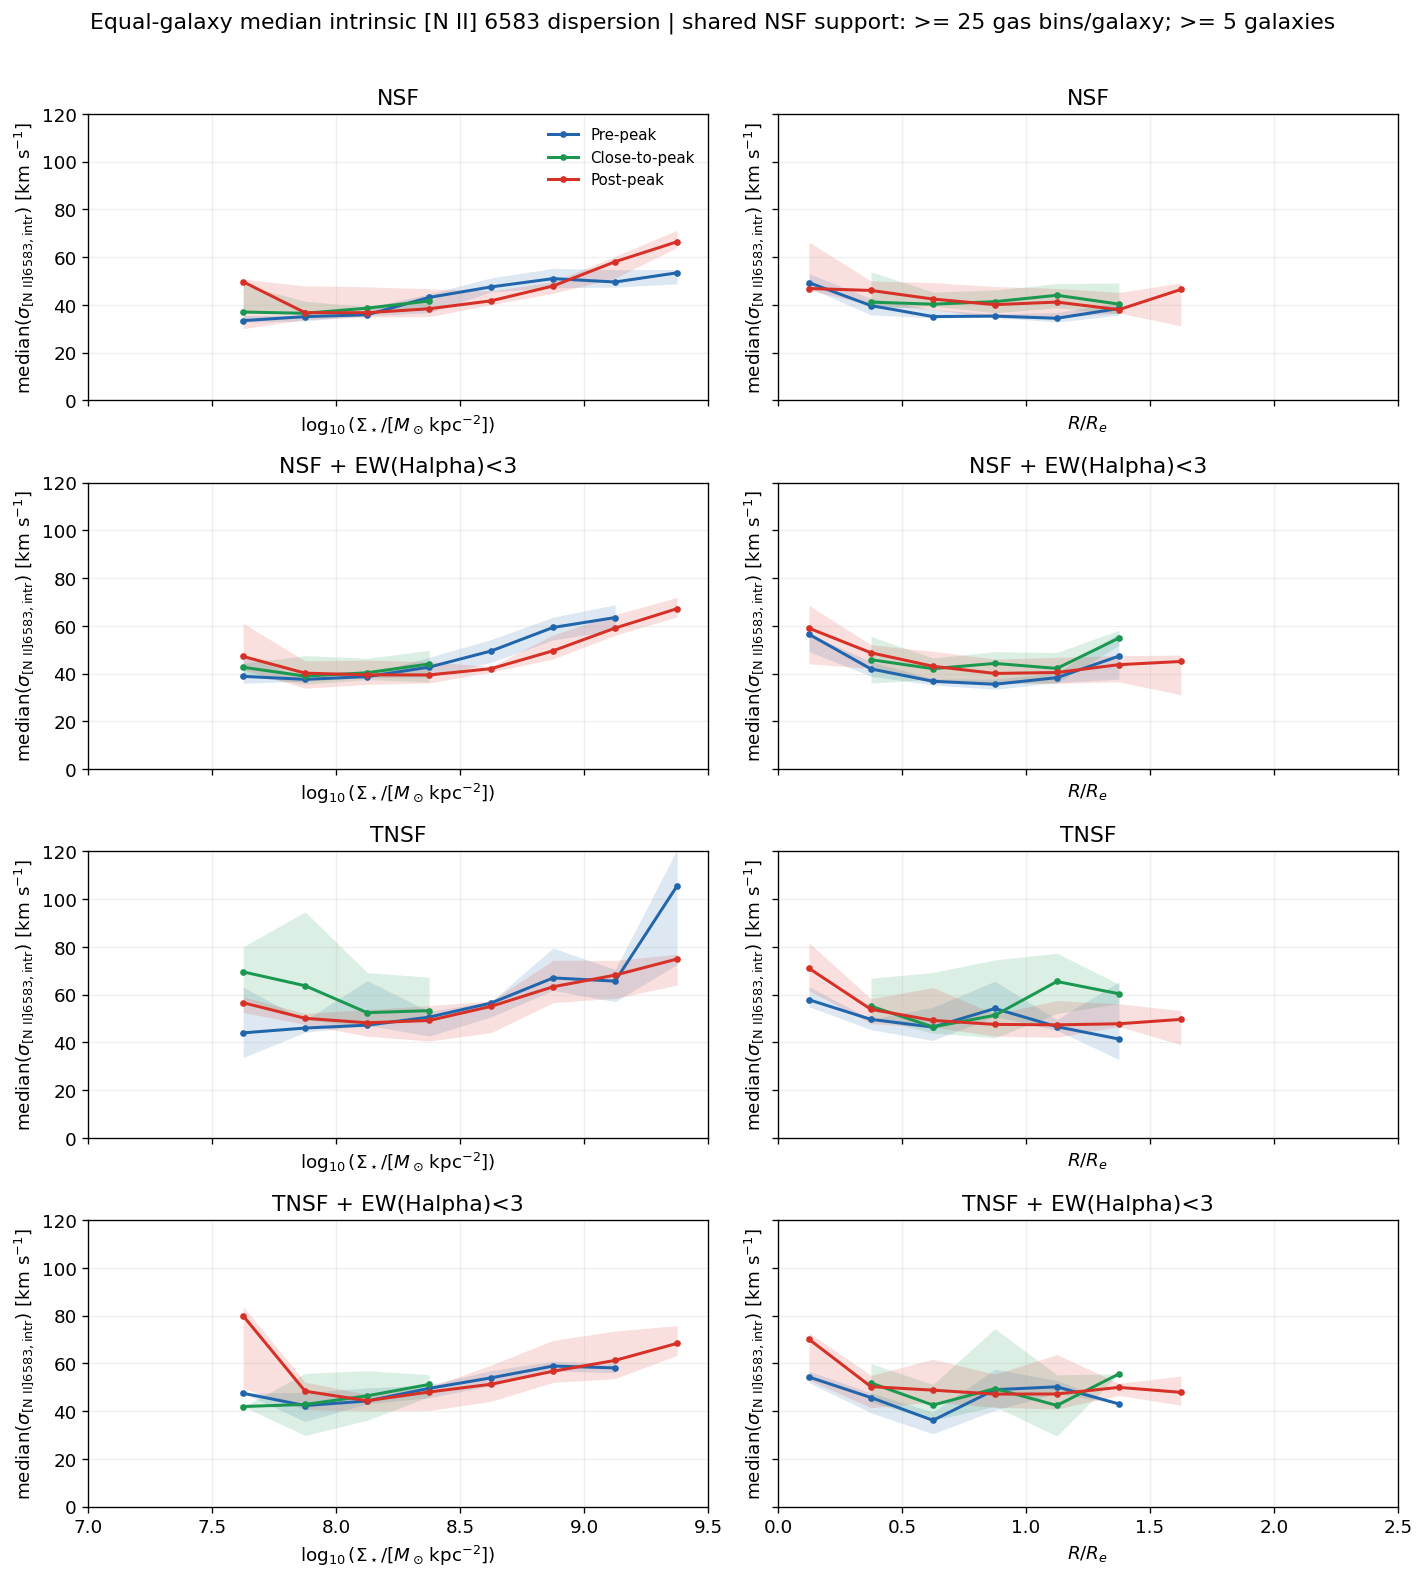

In [7]:
plot_dispersion_comparison("equal")


## Pooled-spaxel dispersion profiles


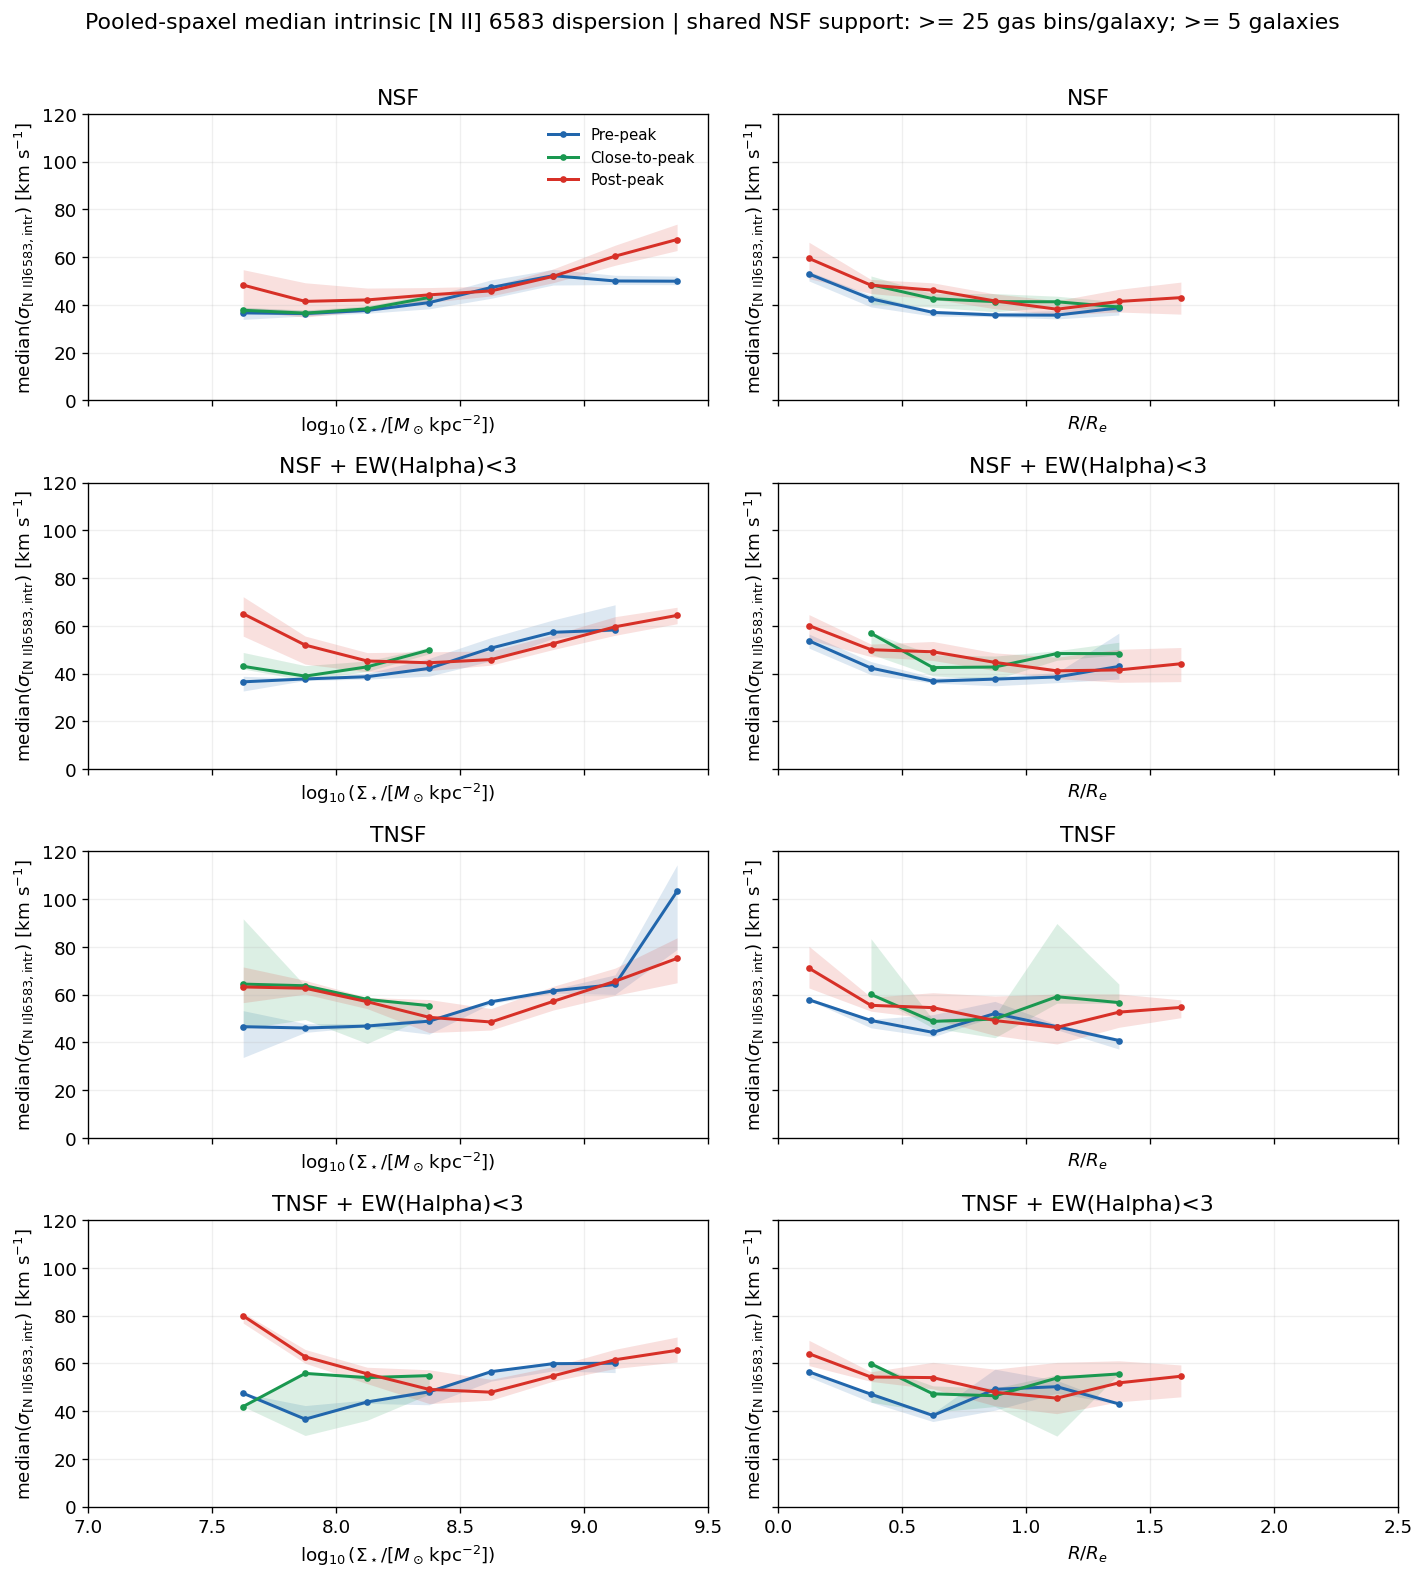

In [8]:
plot_dispersion_comparison("pooled")


## Numerical checks and values beyond the display cap

The numerical values below retain the full measurement range.


In [9]:
checks = {
    "median_estimator_labels": all("median" in label for label in BRANCH_LABELS.values()),
    "nsf_support_gate": bool(NSF_SUPPORT_BY_GALAXY_BIN.NSF_eligible_galaxy.equals(nsf_profile_supported(NSF_SUPPORT_BY_GALAXY_BIN))),
    "shared_nsf_eligibility": bool(DISPERSION_BY_GALAXY_BIN.groupby(["GALID","stage","variable","bin_left"]).NSF_eligible_galaxy.nunique().eq(1).all()),
    "distinct_bins_within_finite_pixels": bool(DISPERSION_BY_GALAXY_BIN.N_unique_gas_bins.le(DISPERSION_BY_GALAXY_BIN.N_sigma_NII6583).all()),
    "four_categories": set(DISPERSION_BY_GALAXY_BIN.category) == set(CATEGORY_ORDER),
    "exact_tnsf_mask": bool(all_masks_exact),
    "finite_sigma_formula": bool(np.allclose(intrinsic_sigma_from_maps(np.array([50.,20.,10.]),np.array([30.,20.,20.])),[40.,np.nan,np.nan],equal_nan=True)),
    "all_categories_in_both_weightings": all(set(t.category) == set(CATEGORY_ORDER) for t in SIGMA_TABLES.values()),
    "consistent_usable_denominator": bool(DISPERSION_BY_GALAXY_BIN.groupby(["GALID","variable","bin_left"]).N_usable.nunique().eq(1).all()),
    "finite_counts_within_selected": bool((DISPERSION_BY_GALAXY_BIN.N_sigma_NII6583 <= DISPERSION_BY_GALAXY_BIN.N_category).all()),
    "shared_0_120_display": DISPERSION_YLIM == (0.,120.),
}
for branch,table in SIGMA_TABLES.items():
    checks[branch+"_nsf_stage_support_gate"] = bool(table.eligible_stage.equals(table.N_NSF_gal_support.ge(MIN_GALAXIES_PER_STAGE_BIN)))
    checks[branch+"_rejected_estimates_unavailable"] = bool(table.loc[~table.eligible_stage,["value","value_lo","value_hi"]].isna().all().all())
    intervals = table.dropna(subset=["value_lo","value_hi"])
    checks[branch+"_intervals_ordered"] = bool(intervals.value_lo.le(intervals.value_hi).all())
display(pd.Series(checks,name="passed").to_frame())
assert all(checks.values()),checks
OUTSIDE_DISPLAY = pd.concat([t.assign(weighting=b) for b,t in SIGMA_TABLES.items()],ignore_index=True)
OUTSIDE_DISPLAY = OUTSIDE_DISPLAY.loc[OUTSIDE_DISPLAY.in_fixed_reliable_range & OUTSIDE_DISPLAY.value.gt(DISPERSION_YLIM[1]),
    ["weighting","category","stage","variable","center","value","value_lo","value_hi","N_gal_support"]]
display(OUTSIDE_DISPLAY)
print("DISPERSION_ONLY_NOTEBOOK_VALIDATION_OK")


,passed
median_estimator_labels,True
nsf_support_gate,True
shared_nsf_eligibility,True
distinct_bins_within_finite_pixels,True
four_categories,True
exact_tnsf_mask,True
finite_sigma_formula,True
all_categories_in_both_weightings,True
consistent_usable_denominator,True
finite_counts_within_selected,True


,weighting,category,stage,variable,center,value,value_lo,value_hi,N_gal_support


DISPERSION_ONLY_NOTEBOOK_VALIDATION_OK


## Post-peak spatial check: NSF after the support cuts

Each post-peak galaxy has one NSF map, with support evaluated only in
stellar-density intervals using the same edges and NSF-only support decisions
as the density profiles. Radial-interval support is not applied to these maps.

Light gray: valid-disc pixels failing SNR_POSTFIT >25 or the NSF-based counting
cuts (including the inherited usable/finite-pixel requirements). Dark gray:
SF or ND pixels passing those cuts. Only passing NSF pixels with finite
intrinsic [N II] 6583 dispersion are color-coded, on a shared 0--100 km/s scale.
Unavailable NSF dispersion stays light gray; pixels outside the valid disc
are blank. Values above 100 use the top color and remain in the data.

The counting cuts require >=25 distinct NSF gas bins per galaxy/interval
and >=5 such NSF galaxies per stage/interval. Spatial masks use all common
intervals, without an additional radius or density-range cut.
Magenta dashed contours mark log stellar surface density 7.5
(solar masses per square kpc); cyan contours mark deprojected R/Re=1.5.
No smoothing or interpolation is applied. The four selections in the main
profile plots remain unchanged. Spatial counts report only the density-support NSF panel.


In [10]:
POSTPEAK_SAMPLE = sample.loc[sample.stage.eq("post-peak")].sort_values("GALID")
POSTPEAK_EXCLUDED = SAMPLE_QC.loc[SAMPLE_QC.stage.eq("post-peak") & SAMPLE_QC.QC_flag.ne("OK"), ["GALID","QC_flag"]]
print("QC-passing post-peak galaxies:", ", ".join(POSTPEAK_SAMPLE.GALID))
print("Excluded post-peak products (not mapped)")
display(POSTPEAK_EXCLUDED)
mass_min,mass_max = FIXED_RELIABLE_RANGES["log_sigma_star"]
radius_min,radius_max = FIXED_RELIABLE_RANGES["radius_re"]
post_bins = DISPERSION_BY_GALAXY_BIN.loc[DISPERSION_BY_GALAXY_BIN.stage.eq("post-peak")].copy()
support = post_bins.eligible_stage_profile
low_mass_bin = post_bins.variable.eq("log_sigma_star") & post_bins.bin_left.ge(mass_min) & post_bins.bin_right.le(7.5)
outer_bin = post_bins.variable.eq("radius_re") & post_bins.bin_left.ge(1.5) & post_bins.bin_right.le(radius_max)
POSTPEAK_CONTRIBUTORS = post_bins.loc[support & (low_mass_bin | outer_bin),
    ["GALID","category","variable","bin_left","bin_right","center","N_usable","N_category","N_sigma_NII6583","N_unique_gas_bins","N_NSF_unique_gas_bins","N_NSF_gal_stage_support","values_sigma_NII6583"]].copy()
POSTPEAK_CONTRIBUTORS["region"] = np.where(POSTPEAK_CONTRIBUTORS.variable.eq("log_sigma_star"),"density 7--7.5","radius 1.5--2.5")
POSTPEAK_CONTRIBUTORS["median_sigma"] = POSTPEAK_CONTRIBUTORS.values_sigma_NII6583.map(lambda v: float(np.median(v)))
POSTPEAK_CONTRIBUTORS["p95_sigma"] = POSTPEAK_CONTRIBUTORS.values_sigma_NII6583.map(lambda v: float(np.percentile(v,95)))
POSTPEAK_CONTRIBUTORS["N_sigma_gt100"] = POSTPEAK_CONTRIBUTORS.values_sigma_NII6583.map(lambda v: int(np.count_nonzero(v > 100)))
POSTPEAK_CONTRIBUTORS = POSTPEAK_CONTRIBUTORS.drop(columns="values_sigma_NII6583")
POSTPEAK_CONTRIBUTOR_SUMMARY = POSTPEAK_CONTRIBUTORS.groupby(["category","region","GALID"],observed=True).agg(
    N_supported_bins=("center","size"),N_finite_sigma=("N_sigma_NII6583","sum"),N_sigma_gt100=("N_sigma_gt100","sum"))
print("Galaxies contributing supported profile bins in the questioned regions")
display(POSTPEAK_CONTRIBUTOR_SUMMARY)
display(POSTPEAK_CONTRIBUTORS)


QC-passing post-peak galaxies: IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698
Excluded post-peak products (not mapped)


,GALID,QC_flag
14,NGC4548,missing_mass_product;missing_sfr_product;missi...
16,NGC4579,missing_mass_product;missing_sfr_product;missi...
19,NGC4689,missing_mass_product;missing_sfr_product;missi...


Galaxies contributing supported profile bins in the questioned regions


N_supported_bins  N_finite_sigma  \
category            region          GALID                                       
NSF                 radius 1.5--2.5 NGC4419                 1            8297   
                                    NGC4450                 1            2443   
                                    NGC4457                 1           15560   
                                    NGC4569                 1            8836   
                                    NGC4698                 1           13677   
NSF + EW(Halpha)<3  radius 1.5--2.5 NGC4419                 1            6465   
                                    NGC4450                 1              69   
                                    NGC4457                 1            7024   
                                    NGC4569                 1            1624   
                                    NGC4698                 1            7929   
TNSF                radius 1.5--2.5 NGC4419                 1            2807   
                                    NGC4450                 1             112   
                                    NGC4457                 1            3129   
                                    NGC4569                 1            3407   
                                    NGC4698                 1             407   
TNSF + EW(Halpha)<3 radius 1.5--2.5 NGC4419                 1            2763   
                                    NGC4457                 1            1430   
                                    NGC4569                 1             293   
                                    NGC4698                 1             294   

                                             N_sigma_gt100  
category            region          GALID                   
NSF                 radius 1.5--2.5 NGC4419            310  
                                    NGC4450              0  
                                    NGC4457            422  
                                    NGC4569            466  
                                    NGC4698              0  
NSF + EW(Halpha)<3  radius 1.5--2.5 NGC4419            310  
                                    NGC4450              0  
                                    NGC4457              0  
                                    NGC4569            110  
                                    NGC4698              0  
TNSF                radius 1.5--2.5 NGC4419            234  
                                    NGC4450              0  
                                    NGC4457             77  
                                    NGC4569            391  
                                    NGC4698              0  
TNSF + EW(Halpha)<3 radius 1.5--2.5 NGC4419            234  
                                    NGC4457              0  
                                    NGC4569             35  
                                    NGC4698              0

,GALID,category,variable,bin_left,bin_right,center,N_usable,N_category,N_sigma_NII6583,N_unique_gas_bins,N_NSF_unique_gas_bins,N_NSF_gal_stage_support,region,median_sigma,p95_sigma,N_sigma_gt100
2488,NGC4419,NSF,radius_re,1.5,1.75,1.625,10310,8297,8297,1431,1431,5,radius 1.5--2.5,56.641422,94.924866,310
2489,NGC4419,NSF + EW(Halpha)<3,radius_re,1.5,1.75,1.625,10310,6465,6465,1099,1431,5,radius 1.5--2.5,57.262997,99.872025,310
2490,NGC4419,TNSF,radius_re,1.5,1.75,1.625,10310,2807,2807,463,1431,5,radius 1.5--2.5,61.986423,112.774353,234
2491,NGC4419,TNSF + EW(Halpha)<3,radius_re,1.5,1.75,1.625,10310,2763,2763,454,1431,5,radius 1.5--2.5,61.959408,113.145309,234
2704,NGC4450,NSF,radius_re,1.5,1.75,1.625,63908,2443,2443,28,28,5,radius 1.5--2.5,31.180418,51.119537,0
2705,NGC4450,NSF + EW(Halpha)<3,radius_re,1.5,1.75,1.625,63908,69,69,1,28,5,radius 1.5--2.5,25.461536,25.461536,0
2706,NGC4450,TNSF,radius_re,1.5,1.75,1.625,63908,112,112,1,28,5,radius 1.5--2.5,24.476061,24.476061,0
2920,NGC4457,NSF,radius_re,1.5,1.75,1.625,19251,15560,15560,1128,1128,5,radius 1.5--2.5,49.163368,88.456818,422
2921,NGC4457,NSF + EW(Halpha)<3,radius_re,1.5,1.75,1.625,19251,7024,7024,535,1128,5,radius 1.5--2.5,47.770737,69.633377,0
2922,NGC4457,TNSF,radius_re,1.5,1.75,1.625,19251,3129,3129,190,1128,5,radius 1.5--2.5,53.298313,83.224869,77


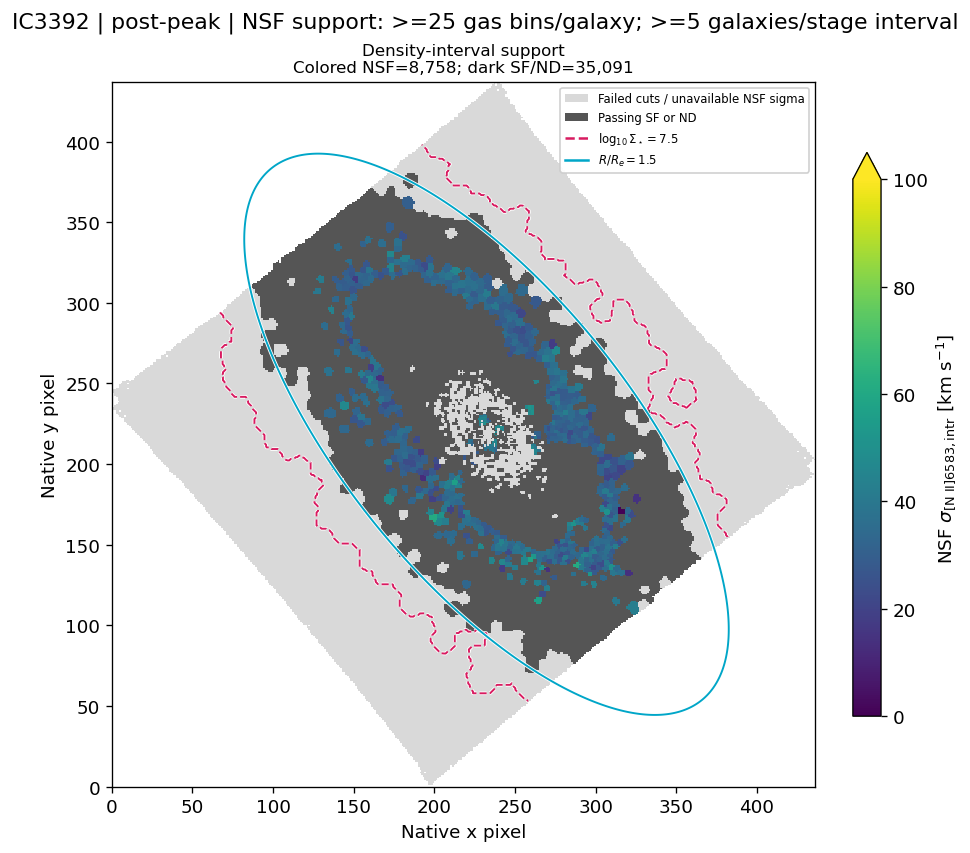

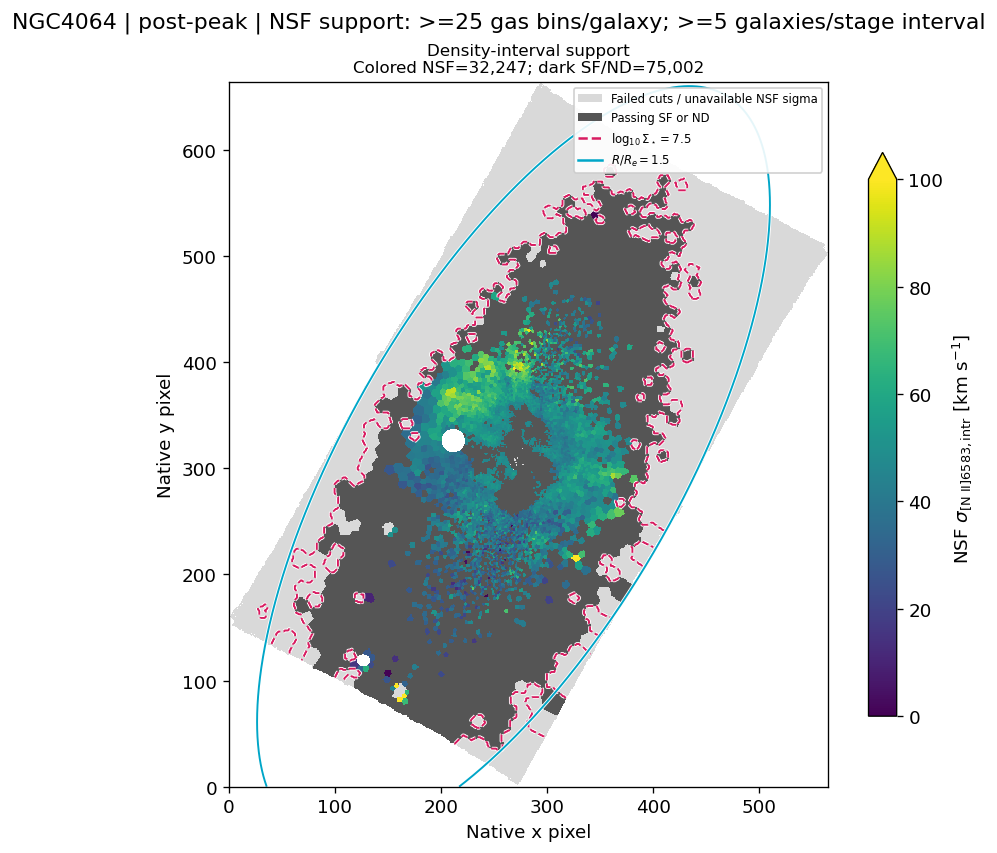

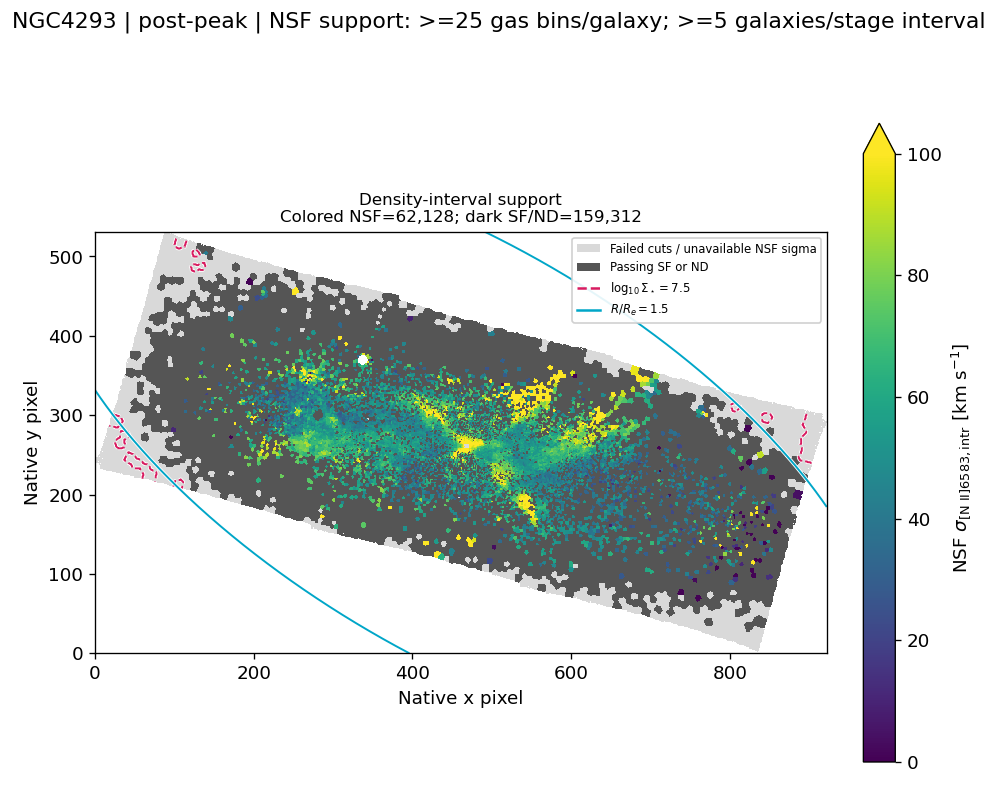

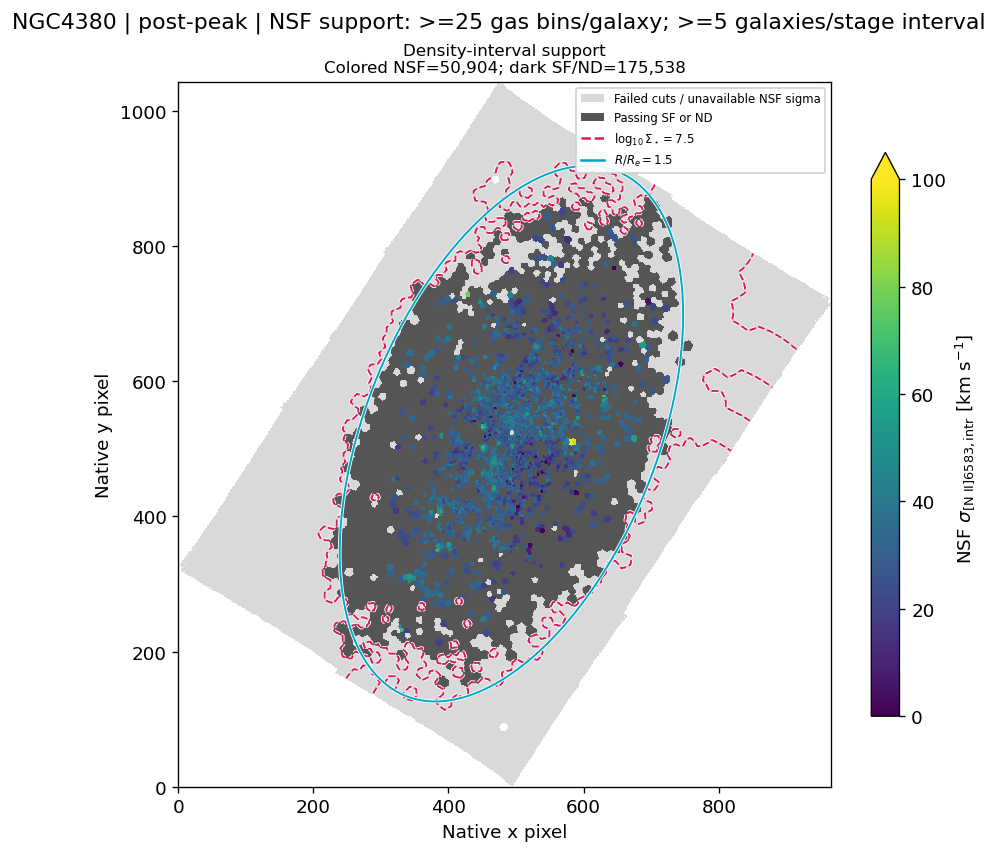

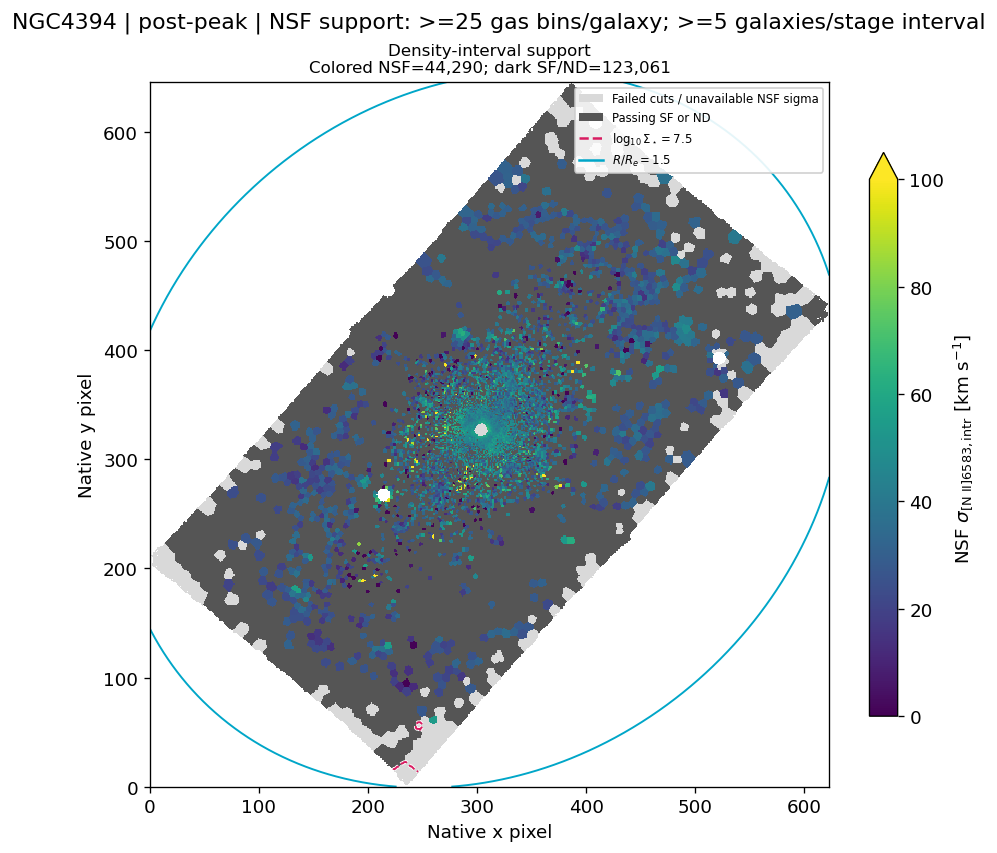

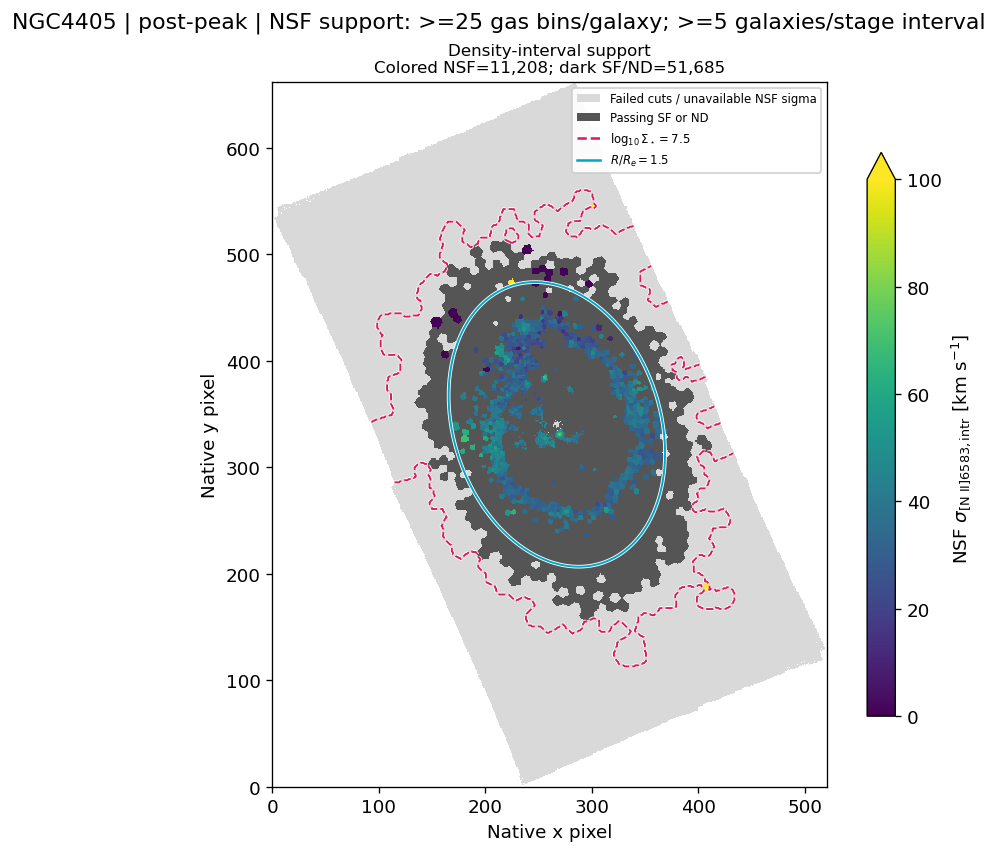

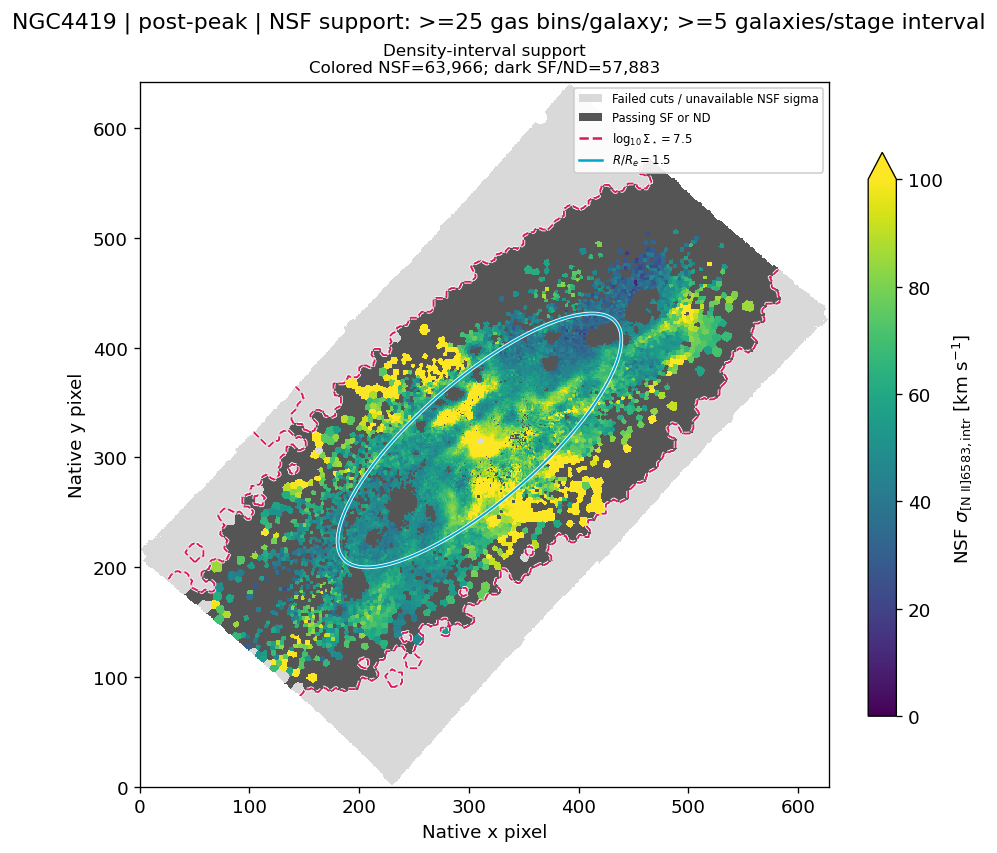

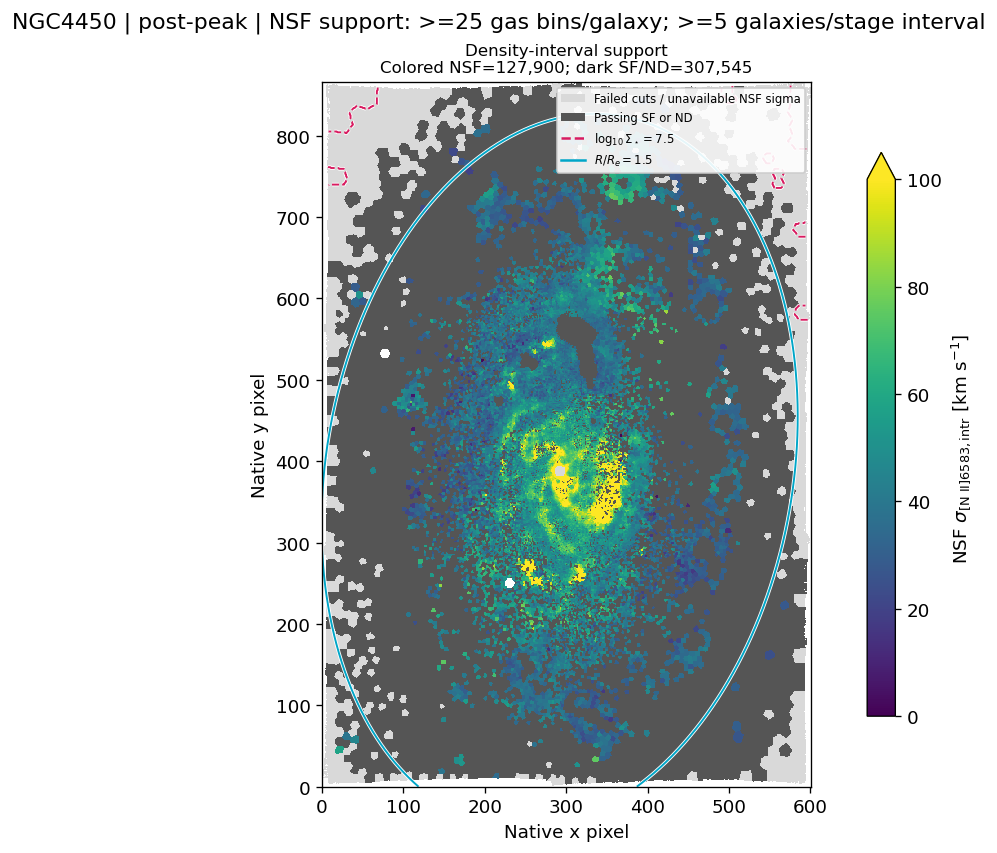

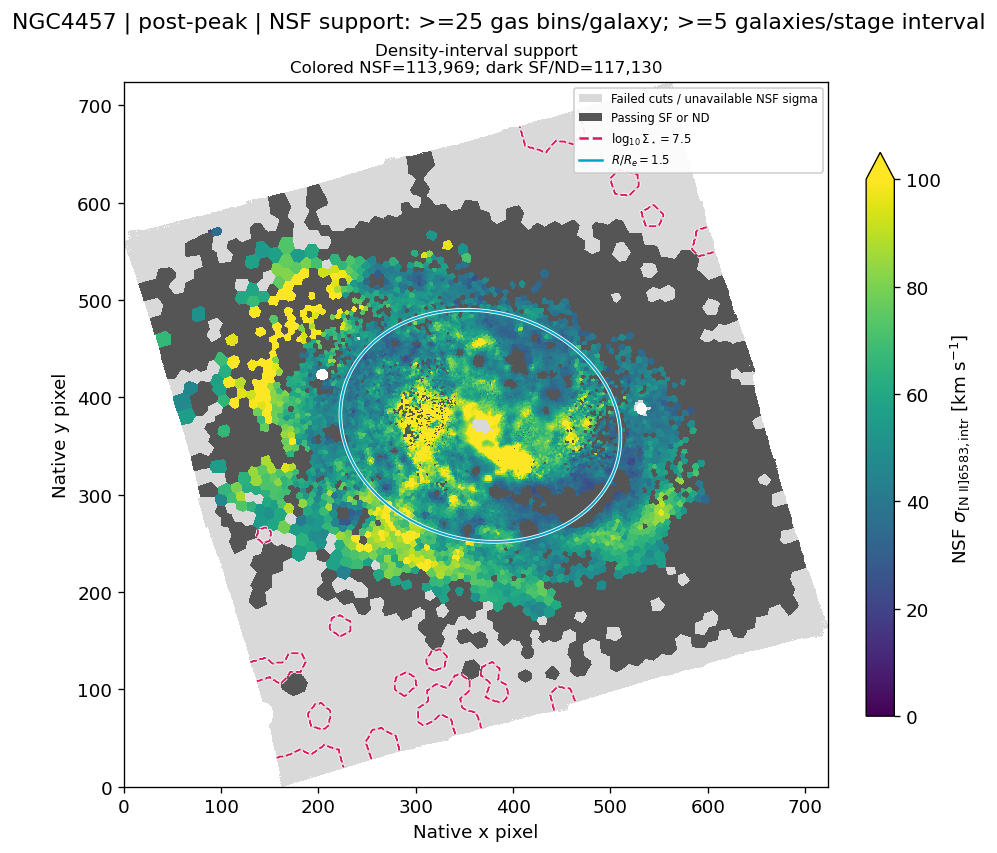

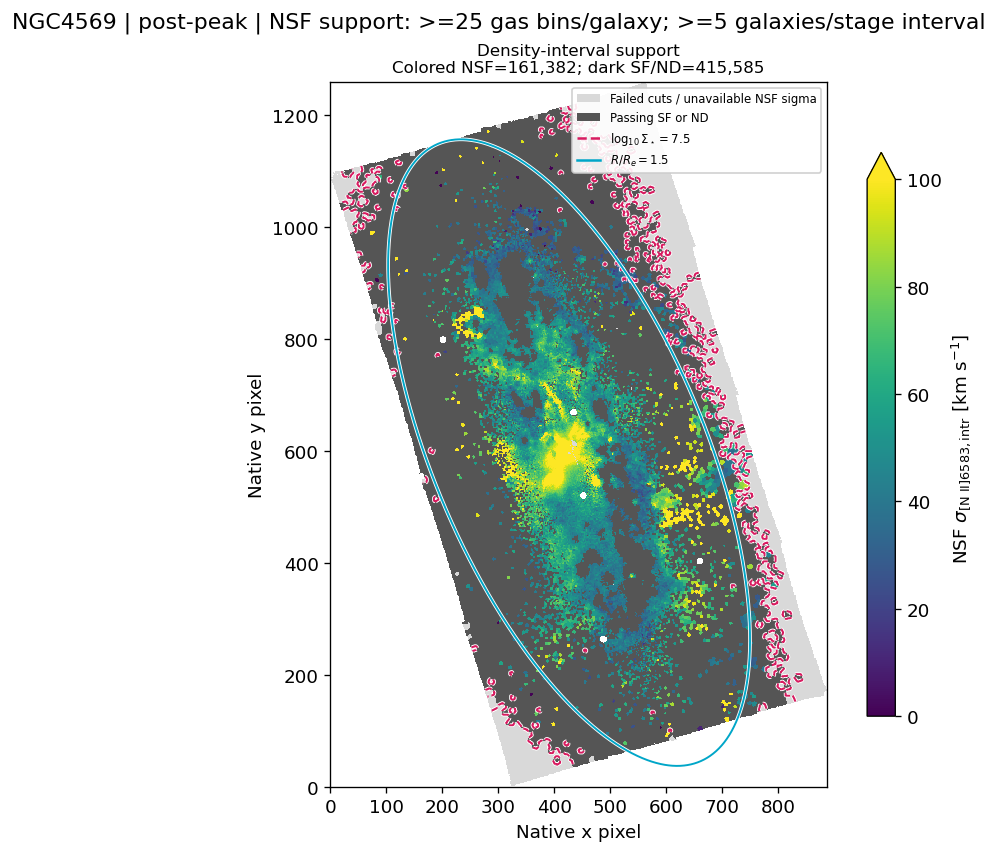

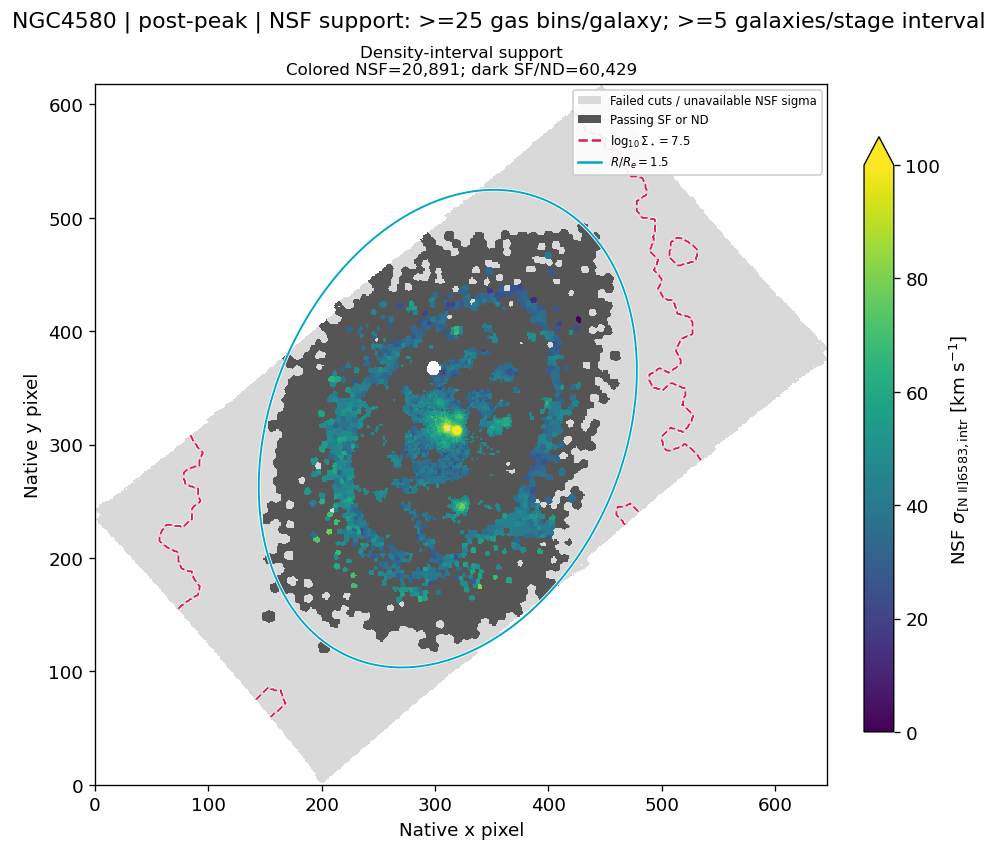

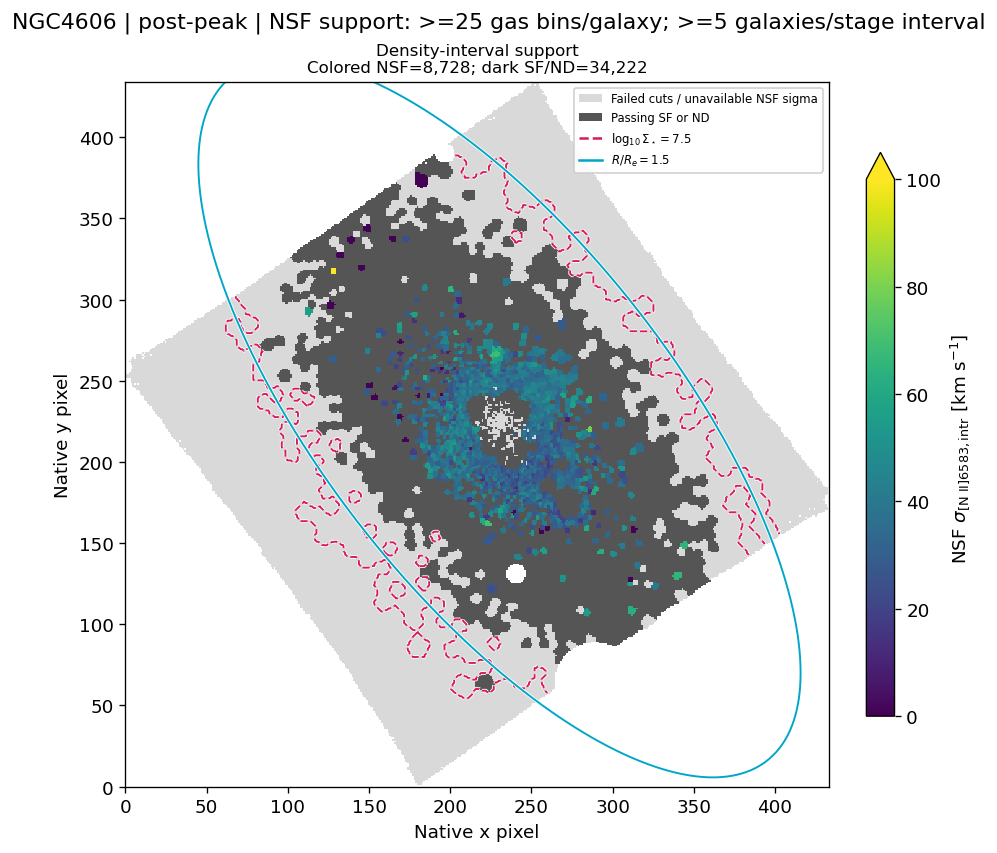

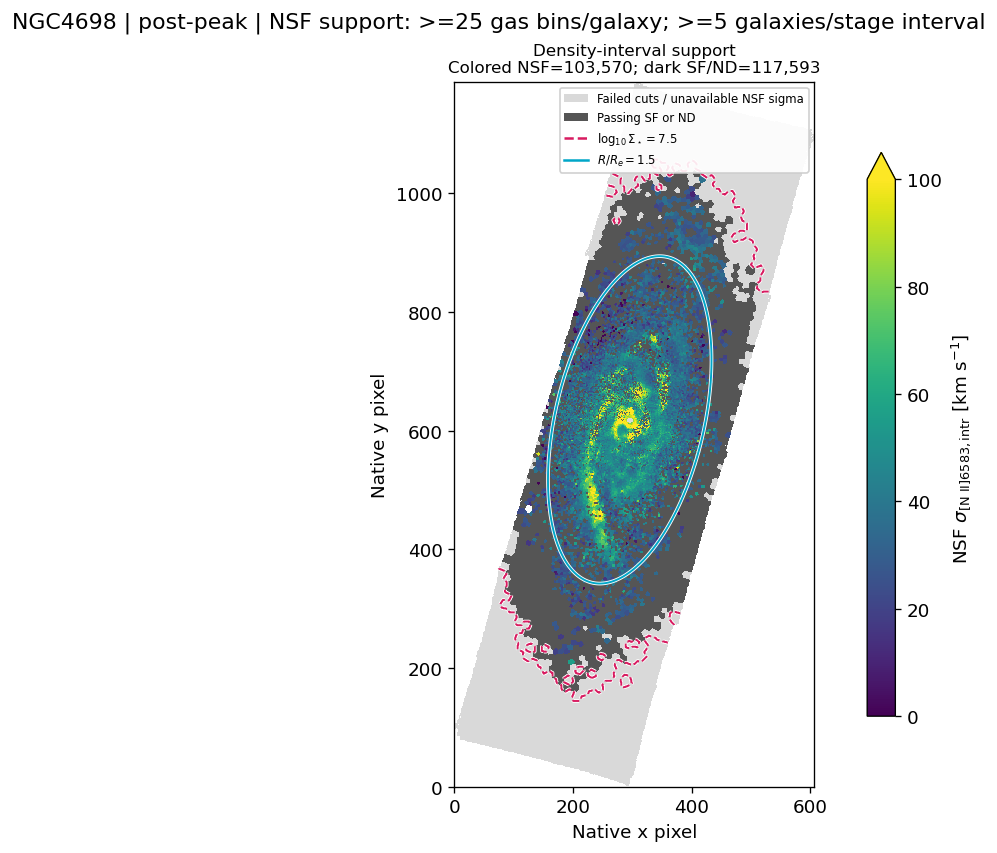

,GALID,variable,N_valid,N_failed_SNR,N_failed_counting_after_SNR,N_dark_SF_ND,N_colored_NSF,N_passing_NSF_sigma_unavailable,N_colored_density_lt7p5,N_colored_radius_gt1p5
0,IC3392,log_sigma_star,94575,37545,13181,35091,8758,0,0,0
1,NGC4064,log_sigma_star,179882,51476,21157,75002,32247,0,0,0
2,NGC4293,log_sigma_star,261523,7726,32357,159312,62128,0,0,0
3,NGC4380,log_sigma_star,502065,268370,7253,175538,50904,0,0,0
4,NGC4394,log_sigma_star,180654,5931,7372,123061,44290,0,0,0
5,NGC4405,log_sigma_star,178518,99842,15783,51685,11208,0,0,708
6,NGC4419,log_sigma_star,180692,46788,12055,57883,63966,0,0,38805
7,NGC4450,log_sigma_star,501469,29817,36207,307545,127900,0,0,2016
8,NGC4457,log_sigma_star,338082,86865,20118,117130,113969,0,0,66520
9,NGC4569,log_sigma_star,659174,19321,62886,415585,161382,0,0,8129


,GALID,mass_7p5_contour_in_valid_disc,radius_1p5_contour_in_native_field
0,IC3392,True,True
1,NGC4064,True,True
2,NGC4293,True,True
3,NGC4380,True,True
4,NGC4394,True,True
5,NGC4405,True,True
6,NGC4419,True,True
7,NGC4450,True,True
8,NGC4457,True,True
9,NGC4569,True,True


In [11]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe

spatial_count_rows,contour_rows = [],[]
POSTPEAK_MAP_GALAXIES = []
SPATIAL_MASK_CHECKS = []
def draw_threshold_contour(ax,values,level,color,style):
    good = np.isfinite(values)
    present = bool(good.any() and np.min(values[good]) < level < np.max(values[good]))
    if present:
        contour = ax.contour(np.ma.masked_invalid(values),levels=[level],colors=[color],linestyles=[style],linewidths=1.15)
        contour.set_path_effects([pe.Stroke(linewidth=2.2,foreground="white"),pe.Normal()])
    return present

for row in POSTPEAK_SAMPLE.itertuples(index=False):
    maps = load_galaxy_maps(row,geometry)
    valid = maps["valid_disc_mask"]
    keep = valid & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
    density,radius = maps["log_sigma_star"],maps["radius_re"]
    sigma = maps["sigma_intrinsic"]
    sf_nd = maps["sf_mask"] | maps["nd_mask"]
    fig,axes = plt.subplots(1,1,figsize=(8,7),squeeze=False,layout="constrained")
    axes = axes.ravel()
    yy,xx = np.where(valid)
    for ax,variable in zip(axes,("log_sigma_star",)):
        ref = NSF_SUPPORT_BY_GALAXY_BIN.loc[NSF_SUPPORT_BY_GALAXY_BIN.GALID.eq(row.GALID)
            & NSF_SUPPORT_BY_GALAXY_BIN.variable.eq(variable)]
        footprint = np.zeros(valid.shape,dtype=bool)
        for r in ref.itertuples(index=False):
            if r.NSF_eligible_galaxy and r.eligible_stage:
                footprint |= (maps[variable] >= r.bin_left) & (maps[variable] < r.bin_left +
                    SIGMA_BIN_WIDTH)
        footprint &= keep
        colored = footprint & maps["nsf_mask"] & np.isfinite(sigma)
        dark = footprint & sf_nd
        failed = valid & ~footprint
        background = np.full(valid.shape,np.nan)
        background[valid] = 0
        background[dark] = 1
        ax.imshow(np.ma.masked_invalid(background),origin="lower",
            cmap=ListedColormap(["#d9d9d9","#555555"]),vmin=0,vmax=1,interpolation="nearest")
        im = ax.imshow(np.ma.masked_where(~colored,sigma),origin="lower",cmap="viridis",
            vmin=0,vmax=100,interpolation="nearest")
        mass_present = draw_threshold_contour(ax,np.where(valid,density,np.nan),7.5,"#d81b60","--")
        radius_present = draw_threshold_contour(ax,np.where(np.isfinite(radius),radius,np.nan),1.5,"#00a6c8","-")
        ax.set_xlim(max(0,xx.min()-5),min(valid.shape[1]-1,xx.max()+5))
        ax.set_ylim(max(0,yy.min()-5),min(valid.shape[0]-1,yy.max()+5))
        panel = "Density-interval support"
        ax.set_title(panel + f"\nColored NSF={colored.sum():,}; dark SF/ND={dark.sum():,}",fontsize=10)
        ax.set_xlabel("Native x pixel");ax.set_ylabel("Native y pixel");ax.set_aspect("equal")
        expected = DISPERSION_BY_GALAXY_BIN.loc[
            DISPERSION_BY_GALAXY_BIN.GALID.eq(row.GALID)
            & DISPERSION_BY_GALAXY_BIN.variable.eq(variable)
            & DISPERSION_BY_GALAXY_BIN.category.eq("NSF")
            & DISPERSION_BY_GALAXY_BIN.eligible_stage_profile].N_sigma_NII6583.sum()
        SPATIAL_MASK_CHECKS.append(bool(colored.sum() == expected
            and not np.any(colored & (~keep | sf_nd))
            and not np.any(dark & (~keep | maps["nsf_mask"]))
            and not np.any((colored | dark) & failed)))
        spatial_count_rows.append({"GALID":row.GALID,"variable":variable,
            "N_valid":int(valid.sum()),"N_failed_SNR":int((valid & ~keep).sum()),
            "N_failed_counting_after_SNR":int((keep & ~footprint).sum()),
            "N_dark_SF_ND":int(dark.sum()),"N_colored_NSF":int(colored.sum()),
            "N_passing_NSF_sigma_unavailable":int((footprint & maps["nsf_mask"] & ~np.isfinite(sigma)).sum()),
            "N_colored_density_lt7p5":int((colored & (density < 7.5)).sum()),
            "N_colored_radius_gt1p5":int((colored & (radius > 1.5)).sum())})
    contour_rows.append({"GALID":row.GALID,"mass_7p5_contour_in_valid_disc":mass_present,
        "radius_1p5_contour_in_native_field":radius_present})
    axes[0].legend(handles=[
        Patch(facecolor="#d9d9d9",label="Failed cuts / unavailable NSF sigma"),
        Patch(facecolor="#555555",label="Passing SF or ND"),
        Line2D([],[],color="#d81b60",ls="--",label=r"$\log_{10}\Sigma_\star=7.5$"),
        Line2D([],[],color="#00a6c8",label=r"$R/R_e=1.5$")],loc="upper right",fontsize=7,framealpha=.9)
    fig.colorbar(im,ax=axes,shrink=.8,extend="max",label=r"NSF $\sigma_{\mathrm{[N\ II]}6583,\mathrm{intr}}$ [km s$^{-1}$]")
    fig.suptitle(row.GALID+" | post-peak | NSF support: >=25 gas bins/galaxy; >=5 galaxies/stage interval")
    POSTPEAK_MAP_GALAXIES.append(row.GALID)
    plt.show()
    del maps
POSTPEAK_SPATIAL_COUNTS = pd.DataFrame(spatial_count_rows)
POSTPEAK_CONTOUR_QC = pd.DataFrame(contour_rows)
display(POSTPEAK_SPATIAL_COUNTS)
display(POSTPEAK_CONTOUR_QC)


In [12]:
SPATIAL_CHECKS = {
    "all_passing_postpeak_galaxies_mapped": set(POSTPEAK_MAP_GALAXIES) == set(POSTPEAK_SAMPLE.GALID),
    "one_density_support_panel_per_galaxy": bool(POSTPEAK_SPATIAL_COUNTS.groupby("GALID").size().eq(1).all()
        and POSTPEAK_SPATIAL_COUNTS.variable.eq("log_sigma_star").all()),
    "colors_match_profile_support_and_classification": all(SPATIAL_MASK_CHECKS),
    "complete_pixel_partition": bool(POSTPEAK_SPATIAL_COUNTS.N_valid.eq(
        POSTPEAK_SPATIAL_COUNTS[["N_failed_SNR","N_failed_counting_after_SNR","N_dark_SF_ND",
            "N_colored_NSF","N_passing_NSF_sigma_unavailable"]].sum(axis=1)).all()),
    "contributor_NSF_support": bool(POSTPEAK_CONTRIBUTORS.N_NSF_unique_gas_bins.ge(MIN_DISTINCT_GAS_BINS_PER_BIN).all()
        & POSTPEAK_CONTRIBUTORS.N_NSF_gal_stage_support.ge(MIN_GALAXIES_PER_STAGE_BIN).all()),
}
display(pd.Series(SPATIAL_CHECKS,name="passed").to_frame())
assert all(SPATIAL_CHECKS.values()),SPATIAL_CHECKS
print("POSTPEAK_SPATIAL_VALIDATION_OK")


,passed
all_passing_postpeak_galaxies_mapped,True
one_density_support_panel_per_galaxy,True
colors_match_profile_support_and_classification,True
complete_pixel_partition,True
contributor_NSF_support,True


POSTPEAK_SPATIAL_VALIDATION_OK


### Gas-bin footprints behind the extreme NSF points

These three formerly supported intervals, now rejected by the 25-gas-bin cut, illustrate why a map-pixel count is not a count of
independent fitted spectra. The gas-bin ID and observed sigma are read directly
from the same live gas FITS file. This check establishes which measurements
underlie the former plotted points; it does not validate their physical interpretation.


In [13]:
footprint_rows = []
for galid,variable,lo,hi in (
    ("NGC4419","log_sigma_star",7.0,7.25),
    ("NGC4293","log_sigma_star",7.25,7.5),
    ("NGC4293","radius_re",1.5,1.75),
):
    row = POSTPEAK_SAMPLE.loc[POSTPEAK_SAMPLE.GALID.eq(galid)].iloc[0]
    maps = load_galaxy_maps(row,geometry)
    keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > 25)
    mask = keep & maps["nsf_mask"] & np.isfinite(maps["sigma_intrinsic"]) & (maps[variable] >= lo) & (maps[variable] < hi)
    with fits.open(row.sfr_path,memmap=True) as hdul:
        bins = np.asarray(hdul[BIN_HDU_GAS].data)
        observed = np.asarray(hdul[NII6583_SIGMA_OBS_HDU].data)
        ids = np.unique(bins[mask])
        observed_values = np.unique(observed[mask])
    reference = DISPERSION_BY_GALAXY_BIN.loc[DISPERSION_BY_GALAXY_BIN.GALID.eq(galid) & DISPERSION_BY_GALAXY_BIN.category.eq("NSF") & DISPERSION_BY_GALAXY_BIN.variable.eq(variable) & np.isclose(DISPERSION_BY_GALAXY_BIN.bin_left,lo)].iloc[0]
    assert int(mask.sum()) == reference.N_sigma_NII6583
    assert len(ids) == reference.N_unique_gas_bins
    assert not reference.eligible_profile
    footprint_rows.append({"GALID":galid,"variable":variable,"bin_left":lo,"bin_right":hi,
        "included_in_profiles":bool(reference.eligible_stage_profile),
        "N_NSF_pixels":int(mask.sum()),"N_unique_gas_bins":len(ids),
        "gas_bin_ids":ids.tolist(),"observed_sigma_values":observed_values.tolist(),
        "median_intrinsic_sigma":float(np.median(maps["sigma_intrinsic"][mask]))})
    del maps
POSTPEAK_GAS_BIN_FOOTPRINTS = pd.DataFrame(footprint_rows)
display(POSTPEAK_GAS_BIN_FOOTPRINTS)
print("GAS_BIN_FOOTPRINT_CHECK_OK")


,GALID,variable,bin_left,bin_right,included_in_profiles,N_NSF_pixels,N_unique_gas_bins,gas_bin_ids,observed_sigma_values,median_intrinsic_sigma
0,NGC4419,log_sigma_star,7.00,7.25,False,455,1,[14145.0],[85.66457860741963],70.589154
1,NGC4293,log_sigma_star,7.25,7.50,False,615,3,"[16358.0, 16592.0, 20362.0]","[48.536165962552644, 49.77589009864917, 54.252...",24.242816
2,NGC4293,radius_re,1.50,1.75,False,649,3,"[16358.0, 16518.0, 16592.0]","[48.536165962552644, 49.77589009864917, 54.252...",24.242816


GAS_BIN_FOOTPRINT_CHECK_OK
